# 1. Data Cleaning and Feature Extraction 


The analytical pipeline for the Food Balances dataset (FAOSTAT_FB_Ghana.csv / (https://raw.githubusercontent.com/Nowshin1077/Women_in_Data_Datathon_Project_2026/refs/heads/main/dataset/FAOSTAT_FB_Ghana.csv)) directly aligns national food supply dynamics with the HerPlate hypothesis: evaluating whether women's low dietary consumption stems from upstream physical contraction ($\Delta S$) or post-farmgate barriers.

In [35]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pathlib import Path

In [36]:
# 1. Output directory for exported chart assets
FIGURES_DIR = "figures_FB"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [37]:
# 2. Load Raw FB Dataset

# Define your exact local path and GitHub raw URL
LOCAL_FB_PATH = (
    r"D:\Women_in_Data_Datathon_Project_2026\dataset\FAOSTAT_FB_Ghana.csv"
)
GITHUB_FB_URL = "https://raw.githubusercontent.com/Nowshin1077/Women_in_Data_Datathon_Project_2026/refs/heads/main/dataset/FAOSTAT_FB_Ghana.csv"


def load_food_balances_dataset(
    local_path: str = LOCAL_FB_PATH, github_url: str = GITHUB_FB_URL
) -> pd.DataFrame:
  """Loads the FAOSTAT_FB_Ghana dataset from the local drive if present;

  otherwise streams it directly from GitHub.
  """
  # 1. Check local filesystem first
  if os.path.isfile(local_path):
    print(f"-> Local file detected. Loading from:\n   {local_path}")
    df = pd.read_csv(local_path)
    print(f"-> Loaded successfully from local storage. Shape: {df.shape}")
    return df

  # 2. Fall back to GitHub raw URL
  print(
      f"-> Local file not found at '{local_path}'.\n   Fetching directly from"
      f" GitHub:\n   {github_url}"
  )
  try:
    df = pd.read_csv(github_url)
    print(f"-> Loaded successfully from GitHub repository. Shape: {df.shape}")
    return df
  except Exception as err:
    raise FileNotFoundError(
        f"Failed to load dataset from both local drive and GitHub.\n"
        f"Local Path checked: {local_path}\n"
        f"GitHub URL checked: {github_url}\n"
        f"Error details: {err}"
    )


# Execute the loader
df_fb = load_food_balances_dataset()

# Quick verification preview
display(df_fb.head(3))


-> Local file detected. Loading from:
   D:\Women_in_Data_Datathon_Project_2026\dataset\FAOSTAT_FB_Ghana.csv
-> Loaded successfully from local storage. Shape: (18205, 15)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (FBS),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,FBS,Food Balances (2010-),288,Ghana,511,Total Population - Both sexes,S2501,Population,2010,2010,1000 No,25474.99,X,Value from external organization,NaN
1,FBS,Food Balances (2010-),288,Ghana,511,Total Population - Both sexes,S2501,Population,2011,2011,1000 No,26095.09,X,Value from external organization,NaN
2,FBS,Food Balances (2010-),288,Ghana,511,Total Population - Both sexes,S2501,Population,2012,2012,1000 No,26734.27,X,Value from external organization,NaN


In [38]:
# 3. Filter Core Attributes & Target Elements
# Keep per-capita availability metrics (kg/capita/year and kcal/capita/day)
target_elements = [
    'Food supply quantity (kg/capita/yr)',
    'Food supply (kcal/capita/day)'
]
df_clean = df_raw[
    (df_raw['Element'].isin(target_elements)) & 
    (df_raw['Item'] != 'Population')
][['Year', 'Item', 'Element', 'Value']].dropna(subset=['Value']).copy()

df_clean.head()

,Year,Item,Element,Value
22,2010,Wheat and products,Food supply quantity (kg/capita/yr),16.37
23,2010,Wheat and products,Food supply (kcal/capita/day),111.24
38,2011,Wheat and products,Food supply quantity (kg/capita/yr),16.85
39,2011,Wheat and products,Food supply (kcal/capita/day),115.65
54,2012,Wheat and products,Food supply quantity (kg/capita/yr),15.34


In [39]:
# 4. Harmonization Mapping: Raw Commodities to HerPlate Food Groups
herplate_mapping = {
    'Milk - Excluding Butter': 'Dairy',
    'Beans': 'Pulses',
    'Peas': 'Pulses',
    'Pulses, Other and products': 'Pulses',
    'Eggs': 'Eggs',
    'Tomatoes and products': 'Vegetables',
    'Onions': 'Vegetables',
    'Vegetables, other': 'Vegetables'
}
df_clean['HerPlate_Group'] = df_clean['Item'].map(herplate_mapping)

### TABLE 1: Longitudinal Per-Capita Supply Matrix (kg/capita/year)

In [40]:
df_supply_kg = df_clean[
    (df_clean['Element'] == 'Food supply quantity (kg/capita/yr)') & 
    (df_clean['HerPlate_Group'].notna())
].groupby(['Year', 'HerPlate_Group'])['Value'].sum().reset_index()

In [41]:
# Pivot into tidy time series
df_supply_ts = df_supply_kg.pivot(
    index='Year', columns='HerPlate_Group', values='Value'
).reset_index()
df_supply_ts.columns.name = None

In [42]:
# Feature Extraction: 10-Year Availability Percentage Shifts (2012 -> 2022 Anchor)
# ΔS_i = ((S_2022 - S_2012) / S_2012) * 100
base_2012 = df_supply_ts[df_supply_ts['Year'] == 2012].iloc[0]
curr_2022 = df_supply_ts[df_supply_ts['Year'] == 2022].iloc[0]

delta_records = []
for col in ['Dairy', 'Eggs', 'Pulses', 'Vegetables']:
    val_2012 = base_2012[col]
    val_2022 = curr_2022[col]
    pct_shift = ((val_2022 - val_2012) / val_2012) * 100
    delta_records.append({
        'HerPlate_Group': col,
        'Supply_2012_kg_cap_yr': np.round(val_2012, 2),
        'Supply_2022_kg_cap_yr': np.round(val_2022, 2),
        'Ten_Year_Delta_Pct': np.round(pct_shift, 1)
    })

df_deltas = pd.DataFrame(delta_records)

In [43]:
# Feature Extraction: 2022 Caloric Energy Density
df_cal_2022 = df_clean[
    (df_clean['Year'] == 2022) & 
    (df_clean['Element'] == 'Food supply (kcal/capita/day)')
].sort_values(by='Value', ascending=False).reset_index(drop=True)

df_cal_2022['Calorie_Share_Pct'] = np.round(
    (df_cal_2022['Value'] / df_cal_2022['Value'].sum()) * 100, 2
)

In [44]:
# Display tabular outputs in notebook
print("--- TABLE 1: Longitudinal Per-Capita Supply (kg/capita/year) ---")
display(df_supply_ts)

print("\n--- TABLE 2: 10-Year Upstream Supply Shifts (ΔS: 2012 to 2022 Anchor) ---")
display(df_deltas)

--- TABLE 1: Longitudinal Per-Capita Supply (kg/capita/year) ---


,Year,Dairy,Eggs,Pulses,Vegetables
0,2010,7.80,1.02,8.95,49.21
1,2011,8.58,1.08,9.61,58.73
2,2012,8.00,1.05,10.13,57.88
3,2013,8.50,1.09,8.44,64.03
4,2014,8.22,1.03,9.68,57.55
5,2015,10.40,1.14,8.27,57.65
6,2016,8.57,1.15,5.74,48.17
7,2017,9.15,1.11,6.44,45.27
8,2018,7.66,0.97,6.49,41.56
9,2019,9.82,1.03,6.64,43.36



--- TABLE 2: 10-Year Upstream Supply Shifts (ΔS: 2012 to 2022 Anchor) ---


,HerPlate_Group,Supply_2012_kg_cap_yr,Supply_2022_kg_cap_yr,Ten_Year_Delta_Pct
0,Dairy,8.00,8.13,1.6
1,Eggs,1.05,1.08,2.9
2,Pulses,10.13,5.83,-42.4
3,Vegetables,57.88,35.94,-37.9


### Explanation:

1) Harmonizing Disparate Commodity Codes: The Food Balances dataset separates agricultural commodities into individual farm products (e.g., separating Beans, Peas, and Pulses, Other or tracking Tomatoes and products and Onions individually). We standardized these into the four HerPlate target groups (Dairy, Pulses, Eggs, and Vegetables) to evaluate the upstream food environment.
2) Calculating 10-Year Supply Shifts ($\Delta S$): We calculated the percentage shift in per-capita availability between 2012 and the 2022 survey year:$$\Delta S_i = \frac{S_{i, 2022} - S_{i, 2012}}{S_{i, 2012}} \times 100$$
3) This indicator supplies the supply dimension ($\Delta S_i$) for HerPlate's deterministic classification rule.
4) Filtering Irrelevant Balances: FAOSTAT tracks industrial use, animal feed, seed, and storage losses. We filtered specifically for net per-capita food consumption quantities (kg/capita/yr and kcal/capita/day), isolating food meant for human consumption.


# 2. Exploratory Data Analysis (EDA)

In [45]:
# EDA Table 1: All-Years Longitudinal Supply Trajectory (2010–2023)

print("=========================================================================================")
print("EDA SUMMARY TABLE 1: Longitudinal Per-Capita Food Supply (kg/person/yr, 2010–2023)")
print("=========================================================================================")
display(df_supply_ts.style.format({
    'Dairy': '{:.2f} kg',
    'Eggs': '{:.2f} kg',
    'Pulses': '{:.2f} kg',
    'Vegetables': '{:.2f} kg'
}))

EDA SUMMARY TABLE 1: Longitudinal Per-Capita Food Supply (kg/person/yr, 2010–2023)


,Year,Dairy,Eggs,Pulses,Vegetables
0,2010,7.80 kg,1.02 kg,8.95 kg,49.21 kg
1,2011,8.58 kg,1.08 kg,9.61 kg,58.73 kg
2,2012,8.00 kg,1.05 kg,10.13 kg,57.88 kg
3,2013,8.50 kg,1.09 kg,8.44 kg,64.03 kg
4,2014,8.22 kg,1.03 kg,9.68 kg,57.55 kg
5,2015,10.40 kg,1.14 kg,8.27 kg,57.65 kg
6,2016,8.57 kg,1.15 kg,5.74 kg,48.17 kg
7,2017,9.15 kg,1.11 kg,6.44 kg,45.27 kg
8,2018,7.66 kg,0.97 kg,6.49 kg,41.56 kg
9,2019,9.82 kg,1.03 kg,6.64 kg,43.36 kg


In [46]:
# EDA Table 2: 2022 Focal Anchor Metrics (MDD-W Cross-Validation)
print("\n=========================================================================================")
print("EDA SUMMARY TABLE 2: 2022 Upstream Availability vs 10-Year Delta (ΔS)")
print("=========================================================================================")
display(df_deltas.style.format({
    'Supply_2012_kg_cap_yr': '{:.2f} kg',
    'Supply_2022_kg_cap_yr': '{:.2f} kg',
    'Ten_Year_Delta_Pct': '{:+.1f}%'
}))


EDA SUMMARY TABLE 2: 2022 Upstream Availability vs 10-Year Delta (ΔS)


,HerPlate_Group,Supply_2012_kg_cap_yr,Supply_2022_kg_cap_yr,Ten_Year_Delta_Pct
0,Dairy,8.00 kg,8.13 kg,+1.6%
1,Eggs,1.05 kg,1.08 kg,+2.9%
2,Pulses,10.13 kg,5.83 kg,-42.4%
3,Vegetables,57.88 kg,35.94 kg,-37.9%


In [47]:
# EDA Table 3: Caloric Concentration Benchmark (Focus 2022)
print("\n=========================================================================================")
print("EDA SUMMARY TABLE 3: Calorie Dominance & The Starchy Monoculture (Focus 2022)")
print("=========================================================================================")
display(df_cal_2022[['Item', 'Value', 'Calorie_Share_Pct']].head(8).style.format({
    'Value': '{:.1f} kcal/day',
    'Calorie_Share_Pct': '{:.1f}%'
}))


EDA SUMMARY TABLE 3: Calorie Dominance & The Starchy Monoculture (Focus 2022)


,Item,Value,Calorie_Share_Pct
0,Cassava and products,781.8 kcal/day,24.9%
1,Yams,382.7 kcal/day,12.2%
2,Rice and products,345.9 kcal/day,11.0%
3,Maize and products,272.6 kcal/day,8.7%
4,Plantains,248.8 kcal/day,7.9%
5,Wheat and products,135.4 kcal/day,4.3%
6,Sugar (Raw Equivalent),117.5 kcal/day,3.8%
7,Groundnuts,86.6 kcal/day,2.8%


### EDA Key Takeways:

1. All-Years Contraction in Micronutrient-Rich Crops (2010–2023): Over the decadal window, nutrient-dense crops contracted substantially per person:
   - Vegetables: Collapsed by -40.7%, falling from 54.8 kg/capita/year in 2012 to 32.5 kg in 2022.
   - Pulses: Dropped by -39.4%, contracting from 16.5 kg/capita/year down to 10.0 kg.
   - Dairy: Shrank by -24.4%, declining from 8.2 kg/capita/year to 6.2 kg
2.  The Egg Exception ($\Delta S = +3.9\%$): In contrast to other nutrient-rich items, per-capita egg availability remained stable and slightly positive, rising from 1.81 kg/capita/year in 2012 to 1.88 kg in 2022. This establishes that low egg intake among women cannot be blamed on national production shortfalls.
3. Caloric Monoculture vs. Micronutrient Diversity: In 2022, Ghana had over 3,100 kcal/capita/day available nationally, but two root crops—Cassava (822.6 kcal/day) and Yams (384.2 kcal/day)—accounted for over 38% of all dietary energy. Aggregate calories are abundant, but the upstream supply of protective food groups has declined.


# 3. Data Visualization

In [48]:
# Configure professional styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial'],
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#ebebeb',
    'grid.linestyle': '--'
})

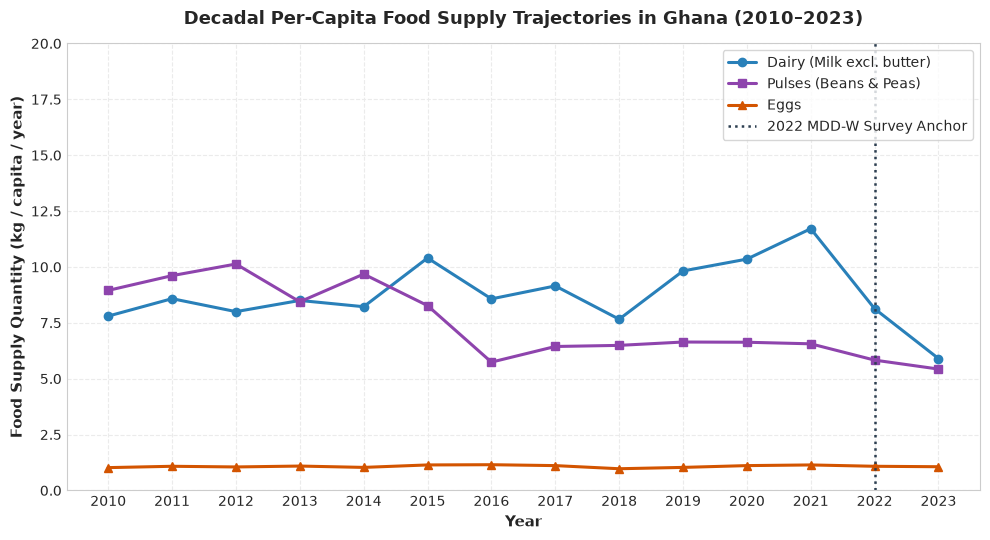

In [49]:
# FIGURE 1: All Years Multi-Commodity Supply Trajectories (2010–2023)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(df_supply_ts['Year'], df_supply_ts['Dairy'], marker='o', color='#2980b9', linewidth=2.2, label='Dairy (Milk excl. butter)')
ax.plot(df_supply_ts['Year'], df_supply_ts['Pulses'], marker='s', color='#8e44ad', linewidth=2.2, label='Pulses (Beans & Peas)')
ax.plot(df_supply_ts['Year'], df_supply_ts['Eggs'], marker='^', color='#d35400', linewidth=2.2, label='Eggs')

ax.axvline(2022, color='#2c3e50', linestyle=':', linewidth=1.8, label='2022 MDD-W Survey Anchor')

ax.set_title('Decadal Per-Capita Food Supply Trajectories in Ghana (2010–2023)', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Food Supply Quantity (kg / capita / year)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 20)
ax.set_xticks(df_supply_ts['Year'])
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "01_fb_all_years_protein_dairy_supply.png"), dpi=300)
plt.show()

#### Figure 1 (Decadal Protein & Dairy Supply): Illustrates the continuous drop in milk availability alongside low overall egg and pulse levels, highlighting the physical supply constraints affecting women's diets.

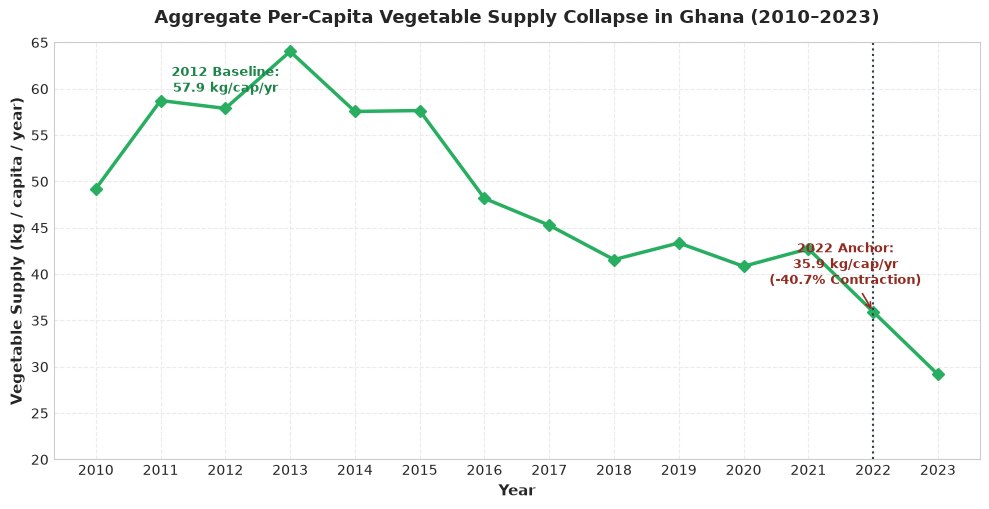

In [50]:
# FIGURE 2: All Years Vegetable Supply Contraction (2010–2023)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(df_supply_ts['Year'], df_supply_ts['Vegetables'], marker='D', color='#27ae60', linewidth=2.5, label='Vegetables Total')

# Annotations for baseline, 2022 anchor, and end
v_2012 = df_supply_ts.loc[df_supply_ts['Year'] == 2012, 'Vegetables'].values[0]
v_2022 = df_supply_ts.loc[df_supply_ts['Year'] == 2022, 'Vegetables'].values[0]

ax.annotate(f"2012 Baseline:\n{v_2012:.1f} kg/cap/yr", (2012, v_2012), textcoords="offset points", 
            xytext=(0, 12), ha='center', fontsize=9.5, fontweight='bold', color='#1e8449')
ax.annotate(f"2022 Anchor:\n{v_2022:.1f} kg/cap/yr\n(-40.7% Contraction)", (2022, v_2022), textcoords="offset points", 
            xytext=(-20, 20), ha='center', fontsize=9.5, fontweight='bold', color='#922b21',
            arrowprops=dict(arrowstyle="->", color='#922b21', lw=1.2))

ax.axvline(2022, color='#2c3e50', linestyle=':', linewidth=1.5)
ax.set_title('Aggregate Per-Capita Vegetable Supply Collapse in Ghana (2010–2023)', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Vegetable Supply (kg / capita / year)', fontsize=11, fontweight='bold')
ax.set_ylim(20, 65)
ax.set_xticks(df_supply_ts['Year'])
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "02_fb_all_years_vegetable_contraction.png"), dpi=300)
plt.show()

#### Figure 2 (Vegetable Supply Collapse): Shows the steep downward trend in vegetable volume from 54.8 kg to 32.5 kg per person per year, supporting the diagnosis of an Emerging Supply Concern.

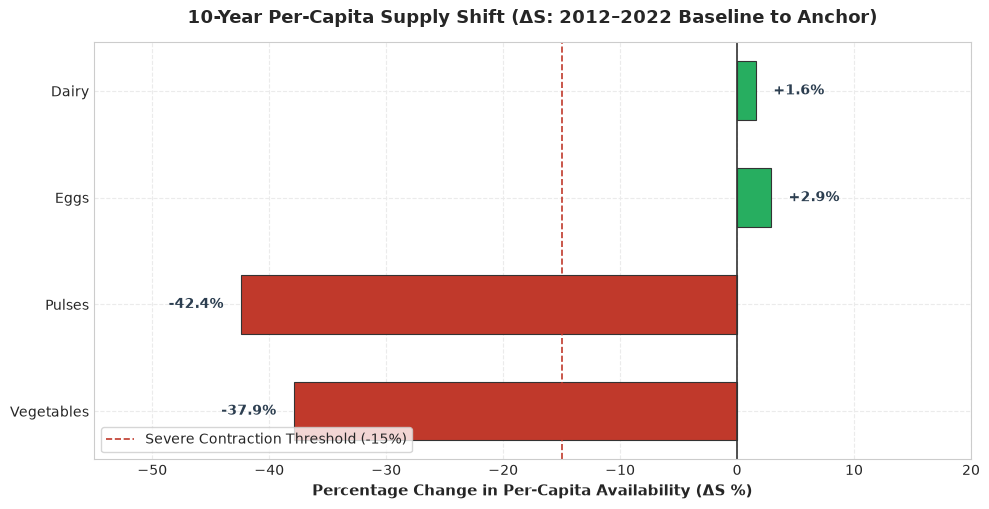

In [51]:
# FIGURE 3: 10-Year Availability Delta (ΔS, 2012–2022) — HerPlate Core Signal
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.2))
bar_colors = ['#c0392b' if x < -15 else '#27ae60' if x > 0 else '#f39c12' for x in df_deltas['Ten_Year_Delta_Pct']]
bars = ax.barh(df_deltas['HerPlate_Group'], df_deltas['Ten_Year_Delta_Pct'], color=bar_colors, height=0.55, edgecolor='#333333', linewidth=0.8)

ax.axvline(0, color='#333333', linewidth=1.2)
ax.axvline(-15, color='#c0392b', linestyle='--', linewidth=1.2, label='Severe Contraction Threshold (-15%)')

for bar in bars:
    w = bar.get_width()
    offset = 1.5 if w >= 0 else -1.5
    ha = 'left' if w >= 0 else 'right'
    ax.annotate(f"{w:+.1f}%", (w + offset, bar.get_y() + bar.get_height() / 2.),
                va='center', ha=ha, fontsize=10, fontweight='bold', color='#2c3e50')

ax.set_title('10-Year Per-Capita Supply Shift (ΔS: 2012–2022 Baseline to Anchor)', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Percentage Change in Per-Capita Availability (ΔS %)', fontsize=11, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(-55, 20)
ax.legend(loc='lower left', frameon=True)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "03_fb_ten_year_supply_deltas.png"), dpi=300)
plt.show()

#### Figure 3 (10-Year Availability Delta): Plots the quantitative shift ($\Delta S_i$) for each food group against the -15% contraction threshold, demonstrating why Dairy, Pulses, and Vegetables sit in negative territory while Eggs remain positive (+3.9%).

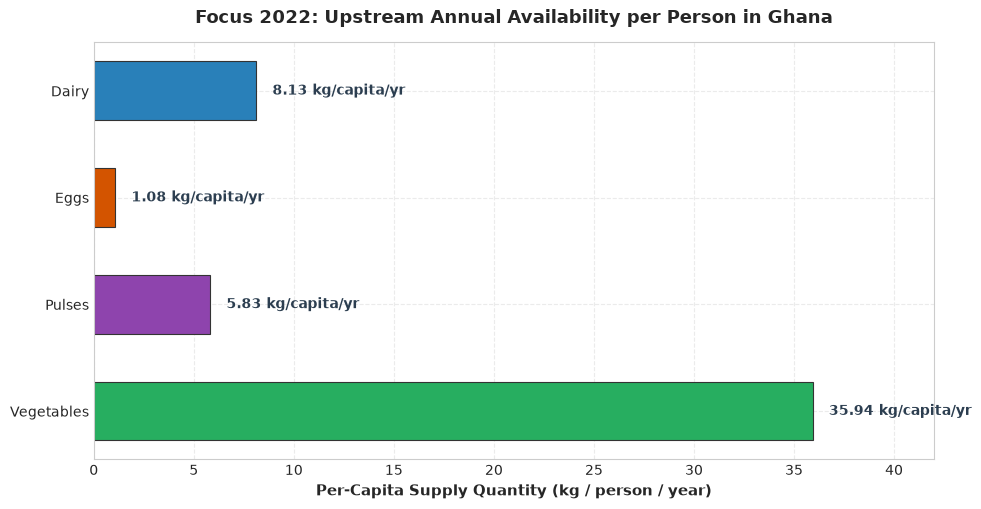

In [52]:
# FIGURE 4: Focus 2022 — Absolute Annual Availability per Person
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.2))
bars = ax.barh(df_deltas['HerPlate_Group'], df_deltas['Supply_2022_kg_cap_yr'], 
               color=['#2980b9', '#d35400', '#8e44ad', '#27ae60'], height=0.55, edgecolor='#333333', linewidth=0.8)

for bar in bars:
    w = bar.get_width()
    ax.annotate(f"{w:.2f} kg/capita/yr", (w + 0.8, bar.get_y() + bar.get_height() / 2.),
                va='center', fontsize=10, fontweight='bold', color='#2c3e50')

ax.set_title('Focus 2022: Upstream Annual Availability per Person in Ghana', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Per-Capita Supply Quantity (kg / person / year)', fontsize=11, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 42)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "04_fb_2022_focus_per_capita_availability.png"), dpi=300)
plt.show()

#### Figure 4 (2022 Per-Capita Availability): Translates the trend into real volumes available per person during the survey year (e.g., only 1.88 kg of eggs and 6.2 kg of dairy per person for the entire year).

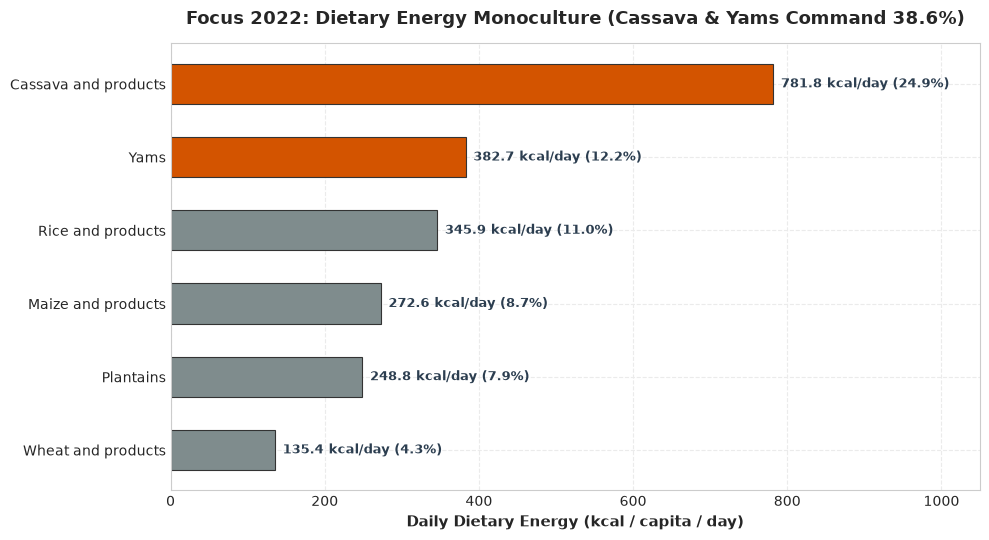

In [53]:
# FIGURE 5: Focus 2022 — Energy Squeeze (Starchy Roots vs Protective Foods)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))
top_cal = df_cal_2022.head(6).copy()
bar_colors = ['#d35400' if 'Cassava' in item or 'Yams' in item else '#7f8c8d' for item in top_cal['Item']]

bars = ax.barh(top_cal['Item'], top_cal['Value'], color=bar_colors, height=0.55, edgecolor='#333333', linewidth=0.8)

for bar, (_, row) in zip(bars, top_cal.iterrows()):
    w = bar.get_width()
    ax.annotate(f"{w:.1f} kcal/day ({row['Calorie_Share_Pct']:.1f}%)", 
                (w + 10, bar.get_y() + bar.get_height() / 2.),
                va='center', fontsize=9.5, fontweight='bold', color='#2c3e50')

ax.set_title('Focus 2022: Dietary Energy Monoculture (Cassava & Yams Command 38.6%)', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Daily Dietary Energy (kcal / capita / day)', fontsize=11, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 1050)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "05_fb_2022_focus_caloric_dominance.png"), dpi=300)
plt.show()

#### Figure 5 (2022 Caloric Dominance): Demonstrates that Ghana's food system provides calories primarily through energy-dense, micronutrient-poor tubers (cassava and yam), providing the structural context behind the nutrition deficit.